## Importar librerias

In [0]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
#import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.metrics import f1_score
import random

## Leer bases

In [0]:
ruta_base = "esan202608.mlops.base_modelo_alto_valor"

In [0]:
# Leer la tabla usando Spark
df_sp = spark.table(ruta_base)

In [0]:
df = df_sp.toPandas()

In [0]:
df.shape

com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$5(SequenceExecutionState.scala:132)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:132)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.can

In [0]:
!pip install xgboost
import xgboost as xgb

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


## Modelo base con parámetros óptimos

In [0]:
# Separar las características y el objetivo
X = df[['periodo_creacion', 'flg_vip', 'tipo_producto_producto_a', 'tipo_producto_producto_b', 'tipo_producto_producto_c', 'monto_1m', 'monto_2m', 'monto_3m', 
        'cantidad_1m', 'cantidad_2m', 'cantidad_3m',
        'ultima_compra_1m', 'crossell']]  # Características
y = df['flg_churn']  # Variable objetivo

# Realizar el train-test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,  # 30% para el conjunto de prueba
    stratify=y,  # Estratificación por la variable objetivo
    random_state=42  # Semilla para reproducibilidad
)

## Modelo base 

In [0]:
def entrenar_xgboost_rapido(X_train, X_test, y_train, y_test):
    """
    Entrena un modelo XGBoost para un problema de clasificación binaria utilizando
    parámetros óptimos previamente obtenidos.
    """
    # Parámetros óptimos (reemplaza con los que obtuviste en el GridSearch)
    parametros_optimos = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'use_label_encoder': False,
        'n_estimators': 50,
        'max_depth': 5,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42
    }
    
    # Crear y entrenar el modelo
    xgb_model = xgb.XGBClassifier(**parametros_optimos)
    xgb_model.fit(X_train, y_train)
    
    # Predicciones
    y_pred = xgb_model.predict(X_test)
    y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]
    
    # Evaluar el modelo
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_prob):.4f}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    
    return xgb_model

In [0]:
modelo_final = entrenar_xgboost_rapido(X_train, X_test, y_train, y_test)


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     24834
           1       0.67      0.48      0.56       581

    accuracy                           0.98     25415
   macro avg       0.83      0.74      0.78     25415
weighted avg       0.98      0.98      0.98     25415

AUC-ROC: 0.9233
Accuracy: 0.9828


## Entrenar modelos con seleccion de variable GA

In [0]:
def feature_selection_ga(X, y, generations=10, population_size=20, mutation_rate=0.3, tournament_size=3, seleccion = "tournament"):
    """
    Realiza selección de características usando un algoritmo genético con XGBoost como modelo base.
    Se puede utilizar el algoritmo de xgboost o random forest
    Se puede usar tounament selection o fitness scaling
    """
    # Dividir datos en entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    n_features = X.shape[1]

    # Función para inicializar la población heurísticamente
    def initialize_population(size):
        population = []
        for _ in range(size):
            individual = np.random.choice([0, 1], size=n_features, p=[0.5, 0.5])
            population.append(individual)
        return np.array(population)

    # Función para evaluar el fitness
    def evaluate_fitness(individual):
        selected_features = np.where(individual == 1)[0]
        if len(selected_features) == 0:  # Penalizar soluciones sin características
            return 0
        X_train_selected = X_train.iloc[:, selected_features]
        X_test_selected = X_test.iloc[:, selected_features]
        
        model = xgb.XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=42
        )
        model.fit(X_train_selected, y_train)
        y_pred = model.predict(X_test_selected)
        return f1_score(y_test, y_pred, average='macro')

    # Selección por torneo
    def tournament_selection(population, fitness_scores, k):
        selected = []
        for _ in range(k):
            participants = np.random.choice(len(population), size=tournament_size, replace=False)
            best = participants[np.argmax(fitness_scores[participants])]
            selected.append(population[best])
        return np.array(selected)
    
    def fitness_scaling_selection(population, fitness_scores, k):
        # Escalar los valores de fitness: normaliza entre 0 y 1
        min_fitness = np.min(fitness_scores)
        max_fitness = np.max(fitness_scores)
        
        if max_fitness == min_fitness:  # Evitar división por cero
            scaled_fitness = np.ones_like(fitness_scores)
        else:
            scaled_fitness = (fitness_scores - min_fitness) / (max_fitness - min_fitness)
        
        # Convertir los valores escalados en probabilidades de selección
        selection_probabilities = scaled_fitness / np.sum(scaled_fitness)
        
        # Seleccionar individuos basados en las probabilidades
        selected_indices = np.random.choice(len(population), size=k, replace=True, p=selection_probabilities)
        selected = population[selected_indices]
        
        return np.array(selected)
    
    # Cruce (crossover)
    def crossover(parent1, parent2):
        point = random.randint(1, n_features - 1)
        child1 = np.concatenate([parent1[:point], parent2[point:]])
        child2 = np.concatenate([parent2[:point], parent1[point:]])
        return child1, child2

    # Mutación
    def mutate(individual):
        for i in range(len(individual)):
            if random.random() < mutation_rate:
                individual[i] = 1 - individual[i]
        return individual

    # Inicializar población
    population = initialize_population(population_size)
    best_fitness = 0
    best_solution = None
    historial_fitness = []  # Para almacenar el mejor F1 Score de cada generación

    # Algoritmo genético
    for generation in range(generations):
        fitness_scores = np.array([evaluate_fitness(ind) for ind in population])
        
        # Guardar el mejor individuo
        if fitness_scores.max() > best_fitness:
            best_fitness = fitness_scores.max()
            best_solution = population[np.argmax(fitness_scores)]
        
        # Almacenar el mejor F1 Score de la generación
        historial_fitness.append(best_fitness)
        
        print(f"Generación {generation + 1} - Mejor F1 Score: {best_fitness:.4f}")
        
         # Selección
        if seleccion == "tournament":
            selected_population = tournament_selection(population, fitness_scores, population_size // 2)
        else:
            selected_population = fitness_scaling_selection(population, fitness_scores, population_size // 2)
        
        # Reproducción
        next_population = []
        while len(next_population) < population_size:
            parent1, parent2 = random.sample(list(selected_population), 2)
            child1, child2 = crossover(parent1, parent2)
            next_population.extend([mutate(child1), mutate(child2)])
        
        population = np.array(next_population[:population_size])

    # Extraer nombres de las mejores características
    selected_features_indices = np.where(best_solution == 1)[0]
    nombres_mejores_caracteristicas = X.columns[selected_features_indices].tolist()

    return best_solution, nombres_mejores_caracteristicas, historial_fitness

### Xgboost + tournament

In [0]:
df_numeric = df.select_dtypes(include=['number'])

In [0]:
df_numeric

,periodo,id_cliente,tasa,monto_1m,monto_2m,monto_3m,monto_4m,monto_5m,monto_6m,cantidad_1m,cantidad_2m,cantidad_3m,cantidad_6m,frecuencia_1m,frecuencia_2m,frecuencia_3m,ultima_compra_1m,ultima_compra_2m,ultima_compra_3m,flg_churn,periodo_creacion,segmento_pago,crossell,tiempo_permanencia,flg_vip,incidencias_a,incidencias_b,tipo_producto_producto_a,tipo_producto_producto_b,tipo_producto_producto_c,segmento_0,segmento_1,segmento_2,segmento_3,segmento_4,segmento_5,segmento_6,segmento_7,segmento_8,segmento_9,segmento_10
0,202405,24205,0.0344,8.614265,8.671235,8.560942,8.909235,8.881321,8.991749,4.718499,4.795791,4.605170,4.990433,21.0,24.0,21.0,31.0,30.0,31.0,0,202309.0,5812.0,0.0,8,0.0,0.0,3.0,1,0,0,0,0,0,1,0,0,0,0,0,0,0
1,202402,24210,0.0280,8.706978,8.088961,9.271130,8.580825,8.855906,8.302603,3.806662,3.218876,4.317488,3.465736,23.0,16.0,28.0,29.0,30.0,31.0,0,202308.0,7230.0,0.0,6,0.0,0.0,0.0,1,0,0,0,0,1,0,0,0,0,0,0,0,0
2,202408,24210,0.0280,9.060296,8.518652,8.400772,8.322637,7.866761,8.504938,3.761200,3.332205,3.496508,3.401197,22.0,18.0,20.0,31.0,31.0,30.0,0,202308.0,7230.0,0.0,12,0.0,0.0,0.0,1,0,0,0,0,1,0,0,0,0,0,0,0,0
3,202401,24213,0.0344,8.915231,8.998940,9.143281,9.046585,8.802372,9.146495,4.553877,4.543295,4.682131,4.875197,26.0,25.0,25.0,31.0,31.0,30.0,0,202303.0,5812.0,1.0,10,0.0,0.0,0.0,0,0,1,0,0,1,0,0,0,0,0,0,0,0
4,202402,24213,0.0344,8.824237,8.915231,8.998940,9.143281,9.046585,8.802372,4.382027,4.553877,4.543295,4.454347,24.0,26.0,25.0,29.0,31.0,31.0,0,202303.0,5812.0,1.0,11,0.0,0.0,1.0,0,0,1,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84711,202401,74413,0.0280,9.392812,9.595038,9.387574,9.306950,9.267108,9.399116,6.129050,6.091310,6.006353,5.710427,26.0,27.0,26.0,31.0,31.0,30.0,0,202304.0,5411.0,1.0,9,0.0,0.0,7.0,1,0,0,0,0,1,0,0,0,0,0,0,0,0
84712,202402,74413,0.0280,9.502644,9.392812,9.595038,9.387574,9.306950,9.267108,6.129050,6.091310,6.006353,5.710427,25.0,26.0,27.0,29.0,31.0,31.0,0,202304.0,5411.0,1.0,10,0.0,0.0,0.0,1,0,0,0,0,1,0,0,0,0,0,0,0,0
84713,202403,74413,0.0280,9.433932,9.502644,9.392812,9.595038,9.387574,9.306950,6.129050,6.091310,6.006353,5.710427,26.0,25.0,26.0,30.0,29.0,31.0,0,202304.0,5411.0,1.0,11,0.0,0.0,2.0,1,0,0,0,0,1,0,0,0,0,0,0,0,0
84714,202404,74413,0.0280,9.288902,9.433932,9.502644,9.392812,9.595038,9.387574,6.129050,6.091310,6.006353,5.710427,26.0,26.0,25.0,30.0,30.0,29.0,0,202304.0,5411.0,1.0,12,0.0,0.0,0.0,1,0,0,0,0,1,0,0,0,0,0,0,0,0


In [0]:
best_solution, nombres_mejores_caracteristicas, historial_fitness = feature_selection_ga(df_numeric.drop(columns=["id_cliente", "periodo" ,"flg_churn"]), df_numeric[["flg_churn"]], generations=30, population_size=30, seleccion = "tournament")

Generación 1 - Mejor F1 Score: 0.7928
Generación 2 - Mejor F1 Score: 0.7936
Generación 3 - Mejor F1 Score: 0.7936
Generación 4 - Mejor F1 Score: 0.7967
Generación 5 - Mejor F1 Score: 0.7967
Generación 6 - Mejor F1 Score: 0.7967
Generación 7 - Mejor F1 Score: 0.7967
Generación 8 - Mejor F1 Score: 0.7967
Generación 9 - Mejor F1 Score: 0.7967
Generación 10 - Mejor F1 Score: 0.7979
Generación 11 - Mejor F1 Score: 0.7979
Generación 12 - Mejor F1 Score: 0.7979
Generación 13 - Mejor F1 Score: 0.7979
Generación 14 - Mejor F1 Score: 0.7990
Generación 15 - Mejor F1 Score: 0.7990
Generación 16 - Mejor F1 Score: 0.7990
Generación 17 - Mejor F1 Score: 0.7990
Generación 18 - Mejor F1 Score: 0.7990
Generación 19 - Mejor F1 Score: 0.8032
Generación 20 - Mejor F1 Score: 0.8032
Generación 21 - Mejor F1 Score: 0.8032
Generación 22 - Mejor F1 Score: 0.8032
Generación 23 - Mejor F1 Score: 0.8032
Generación 24 - Mejor F1 Score: 0.8032
Generación 25 - Mejor F1 Score: 0.8032
Generación 26 - Mejor F1 Score: 0.

### Xgboost + fitness scaling

In [0]:
best_solution_fs, nombres_mejores_caracteristicas_fs, historial_fitness_fs= feature_selection_ga(df_numeric.drop(columns=["id_cliente", "periodo" ,"flg_churn"]), df_numeric[["flg_churn"]], generations=30, population_size=30, seleccion = "fitness_scaling")

Generación 1 - Mejor F1 Score: 0.7888
Generación 2 - Mejor F1 Score: 0.7920
Generación 3 - Mejor F1 Score: 0.7920
Generación 4 - Mejor F1 Score: 0.7920
Generación 5 - Mejor F1 Score: 0.7955
Generación 6 - Mejor F1 Score: 0.7955
Generación 7 - Mejor F1 Score: 0.7955
Generación 8 - Mejor F1 Score: 0.7955
Generación 9 - Mejor F1 Score: 0.7959
Generación 10 - Mejor F1 Score: 0.7980
Generación 11 - Mejor F1 Score: 0.7980
Generación 12 - Mejor F1 Score: 0.7980
Generación 13 - Mejor F1 Score: 0.7980
Generación 14 - Mejor F1 Score: 0.7980
Generación 15 - Mejor F1 Score: 0.7980
Generación 16 - Mejor F1 Score: 0.7980
Generación 17 - Mejor F1 Score: 0.7980
Generación 18 - Mejor F1 Score: 0.7980
Generación 19 - Mejor F1 Score: 0.7980
Generación 20 - Mejor F1 Score: 0.7980
Generación 21 - Mejor F1 Score: 0.8075
Generación 22 - Mejor F1 Score: 0.8075
Generación 23 - Mejor F1 Score: 0.8075
Generación 24 - Mejor F1 Score: 0.8075
Generación 25 - Mejor F1 Score: 0.8075
Generación 26 - Mejor F1 Score: 0.

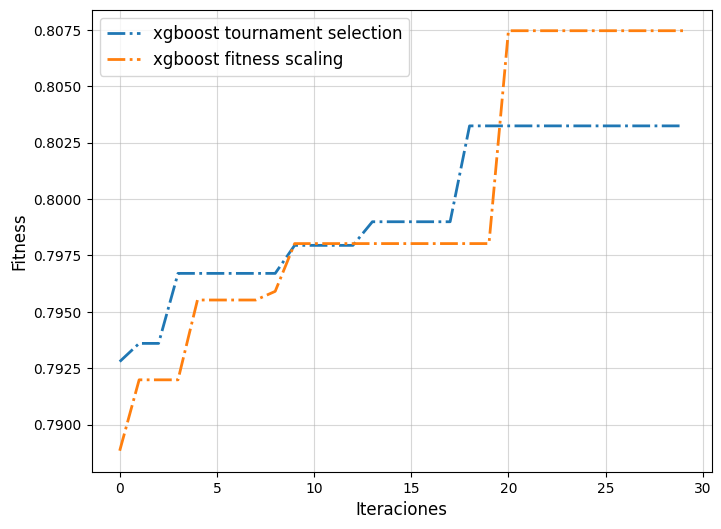

In [0]:
# Crear el gráfico
plt.figure(figsize=(8, 6))  # Tamaño del gráfico
plt.plot([i for i in range(len(historial_fitness))], historial_fitness[:], label="xgboost tournament selection", linestyle="-.", linewidth=2)
plt.plot([i for i in range(len(historial_fitness_fs))], historial_fitness_fs[:], label="xgboost fitness scaling", linestyle="-.", linewidth=2)

# Personalización
#plt.title("F1 Score compartivo Torunament Selection vs Fitness Scaling", fontsize=16)
plt.xlabel("Iteraciones", fontsize=12)
plt.ylabel("Fitness", fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)

plt.show()

## Modelo final

In [0]:
nombres_mejores_caracteristicas

['tasa',
 'monto_1m',
 'monto_2m',
 'monto_4m',
 'frecuencia_1m',
 'ultima_compra_1m',
 'ultima_compra_3m',
 'periodo_creacion',
 'crossell',
 'incidencias_b',
 'tipo_producto_producto_b',
 'tipo_producto_producto_c',
 'segmento_2',
 'segmento_3',
 'segmento_4',
 'segmento_5',
 'segmento_6',
 'segmento_7',
 'segmento_8',
 'segmento_9']

In [0]:
# Separar las características y el objetivo
X = df[nombres_mejores_caracteristicas]  # Características
y = df['flg_churn']  # Variable objetivo

# Realizar el train-test split estratificado
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X, y, 
    test_size=0.3,  # 30% para el conjunto de prueba
    stratify=y,  # Estratificación por la variable objetivo
    random_state=42  # Semilla para reproducibilidad
)

modelo_final_2 = entrenar_xgboost_rapido(X_train_final, X_test_final, y_train_final, y_test_final)


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     24834
           1       0.69      0.59      0.64       581

    accuracy                           0.98     25415
   macro avg       0.84      0.79      0.81     25415
weighted avg       0.98      0.98      0.98     25415

AUC-ROC: 0.9487
Accuracy: 0.9847
